# Data Workflow: Boston Marathon Results (2016–2017)

**Author:** Roberto Jourdain

**Dataset:** Boston Marathon Results (2016 & 2017) — sourced from Kaggle

This project builds a reproducible data workflow using two years of Boston Marathon finishing data. The dataset includes approximately 26,000 runners per year with split times, demographics, and finishing results. The workflow covers data ingestion, cleaning, exploratory analysis, and visualization to uncover patterns in runner performance across both editions.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Ingestion

In [2]:
df_2016 = pd.read_csv("marathon_results_2016.csv")
df_2017 = pd.read_csv("marathon_results_2017.csv")

df_2016["Year"] = 2016
df_2017["Year"] = 2017

df = pd.concat([df_2016, df_2017], ignore_index=True)
df.head()

,Bib,Name,Age,M/F,City,State,Country,Citizen,Unnamed: 8,5K,...,40K,Pace,Proj Time,Official Time,Overall,Gender,Division,Year,Unnamed: 0,Unnamed: 9
0,5,"Hayle, Lemi Berhanu",21,M,Addis Ababa,NaN,ETH,NaN,NaN,0:15:47,...,2:05:59,0:05:04,2:12:45,2:12:45,1,1,1,2016,NaN,NaN
1,1,"Desisa, Lelisa",26,M,Ambo,NaN,ETH,NaN,NaN,0:15:47,...,2:05:59,0:05:06,2:13:32,2:13:32,2,2,2,2016,NaN,NaN
2,6,"Tsegay, Yemane Adhane",31,M,Addis Ababa,NaN,ETH,NaN,NaN,0:15:46,...,2:06:47,0:05:07,2:14:02,2:14:02,3,3,3,2016,NaN,NaN
3,11,"Korir, Wesley",33,M,Kitale,NaN,KEN,NaN,NaN,0:15:46,...,2:06:47,0:05:07,2:14:05,2:14:05,4,4,4,2016,NaN,NaN
4,14,"Lonyangata, Paul",23,M,Eldoret,NaN,KEN,NaN,NaN,0:15:46,...,2:08:11,0:05:11,2:15:45,2:15:45,5,5,5,2016,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53040 entries, 0 to 53039
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Bib            53040 non-null  object 
 1   Name           53040 non-null  object 
 2   Age            53040 non-null  int64  
 3   M/F            53040 non-null  object 
 4   City           53039 non-null  object 
 5   State          46598 non-null  object 
 6   Country        53040 non-null  object 
 7   Citizen        2376 non-null   object 
 8   Unnamed: 8     83 non-null     object 
 9   5K             53040 non-null  object 
 10  10K            53040 non-null  object 
 11  15K            53040 non-null  object 
 12  20K            53040 non-null  object 
 13  Half           53040 non-null  object 
 14  25K            53040 non-null  object 
 15  30K            53040 non-null  object 
 16  35K            53040 non-null  object 
 17  40K            53040 non-null  object 
 18  Pace  

In [4]:
df.isnull().sum()

Bib                  0
Name                 0
Age                  0
M/F                  0
City                 1
State             6442
Country              0
Citizen          50664
Unnamed: 8       52957
5K                   0
10K                  0
15K                  0
20K                  0
Half                 0
25K                  0
30K                  0
35K                  0
40K                  0
Pace                 0
Proj Time            0
Official Time        0
Overall              0
Gender               0
Division             0
Year                 0
Unnamed: 0       26630
Unnamed: 9       52949
dtype: int64

## Data Cleaning

The raw data has several issues that need to be addressed before analysis:

1. **Junk columns** — `Unnamed: 0`, `Unnamed: 8`, `Unnamed: 9` are artifacts from the CSV export (row indices and empty fields). `Citizen` is 95% null and not useful for our analysis.
2. **Time strings** — All split and finish time columns are stored as strings (e.g., `"2:12:45"`). These need to be converted to numeric values (total minutes) so we can perform calculations and create visualizations. The `Proj Time` column also contains `"-"` placeholders in the 2017 data that must be handled.

In [5]:
def drop_unnecessary_columns(dataframe):
    """Remove columns that are CSV artifacts or too sparse to be useful.

    Drops 'Unnamed: 0', 'Unnamed: 8', 'Unnamed: 9' (CSV export artifacts)
    and 'Citizen' (95% null values). Only drops columns that exist in the
    DataFrame to avoid KeyError.

    Args:
        dataframe: pandas DataFrame to clean.

    Returns:
        DataFrame with the unnecessary columns removed.
    """
    cols_to_drop = ["Unnamed: 0", "Unnamed: 8", "Unnamed: 9", "Citizen"]
    cols_present = [c for c in cols_to_drop if c in dataframe.columns]
    return dataframe.drop(columns=cols_present)


def convert_time_columns(dataframe):
    """Convert time-string columns from 'H:MM:SS' format to total minutes.

    Handles missing or placeholder values ('-') by converting them to NaN.
    Applies to all split columns (5K–40K), Half, Pace, Proj Time, and
    Official Time.

    Args:
        dataframe: pandas DataFrame with time columns as strings.

    Returns:
        DataFrame with time columns converted to float (total minutes).
    """
    time_cols = ["5K", "10K", "15K", "20K", "Half", "25K", "30K",
                 "35K", "40K", "Pace", "Proj Time", "Official Time"]

    def time_to_minutes(t):
        if pd.isna(t) or t == "-":
            return np.nan
        parts = str(t).split(":")
        return int(parts[0]) * 60 + int(parts[1]) + int(parts[2]) / 60

    df_out = dataframe.copy()
    for col in time_cols:
        df_out[col] = df_out[col].apply(time_to_minutes)
    return df_out

In [6]:
df = drop_unnecessary_columns(df)
df = convert_time_columns(df)
df.head()

,Bib,Name,Age,M/F,City,State,Country,5K,10K,15K,...,30K,35K,40K,Pace,Proj Time,Official Time,Overall,Gender,Division,Year
0,5,"Hayle, Lemi Berhanu",21,M,Addis Ababa,NaN,ETH,15.783333,31.333333,47.116667,...,94.283333,110.4,125.983333,5.066667,132.750000,132.750000,1,1,1,2016
1,1,"Desisa, Lelisa",26,M,Ambo,NaN,ETH,15.783333,31.350000,47.133333,...,94.283333,110.4,125.983333,5.100000,133.533333,133.533333,2,2,2,2016
2,6,"Tsegay, Yemane Adhane",31,M,Addis Ababa,NaN,ETH,15.766667,31.333333,47.116667,...,94.750000,110.8,126.783333,5.116667,134.033333,134.033333,3,3,3,2016
3,11,"Korir, Wesley",33,M,Kitale,NaN,KEN,15.766667,31.350000,47.116667,...,94.750000,110.8,126.783333,5.116667,134.083333,134.083333,4,4,4,2016
4,14,"Lonyangata, Paul",23,M,Eldoret,NaN,KEN,15.766667,31.350000,47.133333,...,94.766667,111.5,128.183333,5.183333,135.750000,135.750000,5,5,5,2016


## Exploratory Data Analysis

Before visualizing, we explore the data numerically to understand distributions, central tendencies, and how key variables differ across groups.

In [7]:
def summarize_by_group(dataframe, group_col, value_col="Official Time"):
    """Compute summary statistics for a numeric column grouped by a categorical column.

    Returns count, mean, median, standard deviation, min, and max for each
    group. Useful for comparing finish times across gender, year, country, etc.

    Args:
        dataframe: pandas DataFrame with the data.
        group_col: column name to group by (e.g., 'M/F', 'Year', 'Country').
        value_col: numeric column to summarize (default: 'Official Time').

    Returns:
        DataFrame with summary statistics per group, sorted by median.
    """
    summary = dataframe.groupby(group_col)[value_col].agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
    return summary.sort_values("median")

In [8]:
summarize_by_group(df, "M/F")

,count,mean,median,std,min,max
M/F,,,,,,
M,28901,227.409201,219.233333,42.100126,129.616667,505.150000
F,24139,247.482802,238.866667,38.355101,141.866667,630.383333


In [9]:
summarize_by_group(df, "Year")

,count,mean,median,std,min,max
Year,,,,,,
2016,26630,235.043024,228.083333,41.107147,132.750000,630.383333
2017,26410,238.059256,231.658333,42.148053,129.616667,478.233333


In [10]:
summarize_by_group(df, "Country").head(10)

,count,mean,median,std,min,max
Country,,,,,,
ZIM,2,139.850000,139.850000,3.087700,137.666667,142.033333
KEN,16,142.420833,140.708333,8.011135,129.616667,153.666667
BRN,1,142.850000,142.850000,NaN,142.850000,142.850000
UGA,1,144.733333,144.733333,NaN,144.733333,144.733333
ETH,19,149.184211,150.966667,11.336077,132.750000,165.283333
BDI,1,152.400000,152.400000,NaN,152.400000,152.400000
LTU,7,194.966667,190.066667,19.807154,169.850000,230.033333
FLK,2,191.200000,191.200000,1.131371,190.400000,192.000000
MLT,1,194.433333,194.433333,NaN,194.433333,194.433333


**Note on country-level comparisons:** These statistics must be interpreted with caution. Countries like Kenya and Ethiopia are represented almost exclusively by elite, sponsored athletes (small sample sizes), while the United States contributes tens of thousands of runners across the full ability spectrum. Comparing median finish times between these groups as if they are equivalent would be misleading — it reflects **selection bias** in who participates, not a true national-level comparison of running ability.

## Visualizations

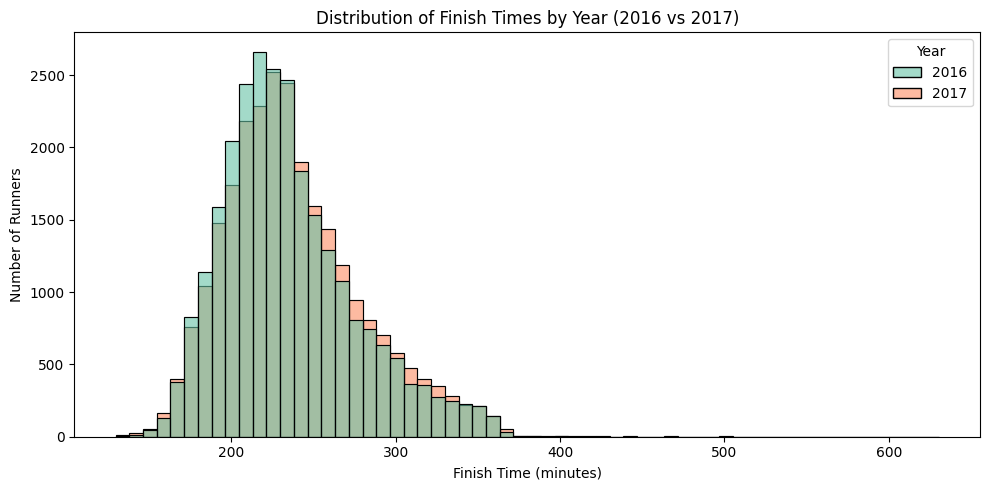

In [11]:
# Figure 1: Distribution of Official Finish Times
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="Official Time", hue="Year", bins=60,
             palette="Set2", alpha=0.6, ax=ax)
ax.set_title("Distribution of Finish Times by Year (2016 vs 2017)")
ax.set_xlabel("Finish Time (minutes)")
ax.set_ylabel("Number of Runners")
plt.tight_layout()
plt.show()

**Figure 1 Interpretation:** The finish time distributions for both years are right-skewed, with the bulk of runners finishing between roughly 180 and 280 minutes (3:00–4:40). The shape is remarkably similar across years, suggesting consistent qualification standards and field composition. The slight skew reflects the Boston Marathon's qualifying requirement — there is a hard floor on ability, but a long tail of slower finishers.

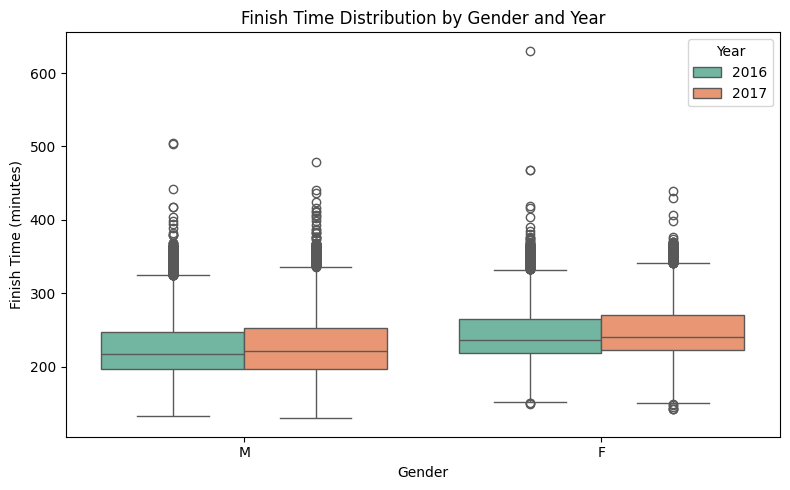

In [12]:
# Figure 2: Finish Times by Gender
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="M/F", y="Official Time", hue="Year",
            palette="Set2", ax=ax)
ax.set_title("Finish Time Distribution by Gender and Year")
ax.set_xlabel("Gender")
ax.set_ylabel("Finish Time (minutes)")
plt.tight_layout()
plt.show()

**Figure 2 Interpretation:** Male runners show a lower median finish time than female runners in both years, which is consistent with known physiological differences and the fact that Boston Marathon qualifying standards are already adjusted by gender. The spread (IQR) is similar for both groups, and both show outliers on the high end — runners who finished well above the typical range.

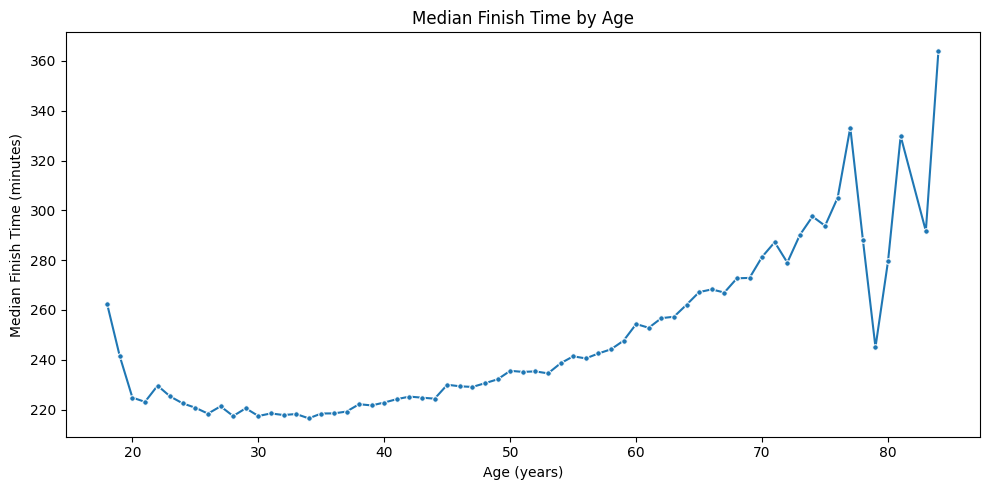

In [13]:
# Figure 3: Median Finish Time by Age
age_summary = df.groupby("Age")["Official Time"].median().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=age_summary, x="Age", y="Official Time", marker="o",
             markersize=4, ax=ax)
ax.set_title("Median Finish Time by Age")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Median Finish Time (minutes)")
plt.tight_layout()
plt.show()

**Figure 3 Interpretation:** Median finish time follows a U-shaped curve — younger runners (18–25) and older runners (65+) tend to have higher finish times, while the fastest median times cluster in the late 20s to mid 30s. The gradual increase after ~40 reflects age-related decline in performance. Noise at the extremes (very young, very old) is expected due to small sample sizes in those age groups.